In [1]:
import os
import sys
import json
import logging
import argparse
import torch

print("MPS available:", torch.backends.mps.is_available())
print("CUDA version:", torch.version.cuda)

# Show MPS device info safely
if torch.backends.mps.is_available():
    print("MPS backend is active on macOS (Metal).")
    print("Device: Apple GPU via Metal Performance Shaders (MPS).")
else:
    print("MPS not available — running on CPU instead.")

print("CPU cores:", os.cpu_count())


MPS available: False
CUDA version: 11.7
MPS not available — running on CPU instead.
CPU cores: 48


In [2]:
import scanpy as sc

# Load your dataset
adata_sc = sc.read_h5ad("./scrna-sciplex3/hvg.h5ad")

# Basic overview
print(adata_sc)
print("Shape:", adata_sc.shape)

# View column names (metadata about each cell)
print("Observation columns:", adata_sc.obs.columns.tolist()[:10])
print("Feature columns:", adata_sc.var_names[:10].tolist())

# How many drugs (conditions)?
print("Unique conditions:", adata_sc.obs['drug'].unique())
print("Number of cells per condition:")
print(adata_sc.obs['drug'].value_counts())



AnnData object with n_obs × n_vars = 762039 × 1000
    obs: 'size_factor', 'cell_type', 'replicate', 'dose', 'drug_code', 'pathway_level_1', 'pathway_level_2', 'product_name', 'target', 'pathway', 'drug', 'drug-dose', 'drug_code-dose', 'n_genes'
    var: 'gene_short_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'pca', 'rank_genes_groups'
    obsm: 'X_pca'
    varm: 'PCs', 'marker_genes-drug-rank', 'marker_genes-drug-score'
Shape: (762039, 1000)
Observation columns: ['size_factor', 'cell_type', 'replicate', 'dose', 'drug_code', 'pathway_level_1', 'pathway_level_2', 'product_name', 'target', 'pathway']
Feature columns: ['ENSG00000243620.1', 'ENSG00000271503.5', 'ENSG00000259124.1', 'ENSG00000121101.15', 'ENSG00000160963.13', 'ENSG00000135346.8', 'ENSG00000143839.14', 'ENSG00000100867.14', 'ENSG00000140986.7', 'ENSG00000230666.5']
Unique conditions: ['tak_901', 'ag_490', 'abexinostat', 'alisertib', 'busulfan', ..., 'ac480', 'cediranib', 't

In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
drug = "trametinib"
X_pre = adata_sc[adata_sc.obs["drug"] == "control"].copy().to_df()
X_post  = adata_sc[adata_sc.obs["drug"] == drug].copy().to_df()

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

top_genes_ids, top_genes_short, top_genes_idx = topk_markers(adata_sc, drug, k=100)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


X_pre cells: (17565, 1000)
X_post cells: (3277, 1000)
(2621, 1000)
(656, 1000)
(2621, 1000)
(656, 1000)
Median heuristic gamma: 0.002284426999219219


In [5]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

import sys
import numpy as np
import pandas as pd
import torch
from typing import Optional, List, Dict

from anndata import AnnData
from sklearn.preprocessing import StandardScaler

import scgen  # pip/conda package "scgen"

# -----------------------------
# scGen AE utilities
# -----------------------------
def _make_scgen_adata(X: np.ndarray, condition: str, var_names: Optional[List[str]], cond_categories: List[str]) -> AnnData:
    X = np.asarray(X, dtype=np.float32)
    if var_names is None:
        var_names = [f"g{i}" for i in range(X.shape[1])]
    obs = pd.DataFrame({
        "condition": pd.Categorical([condition] * X.shape[0], categories=cond_categories),
        "cell_type": pd.Categorical(["all"] * X.shape[0], categories=["all"]),
    })
    var = pd.DataFrame(index=pd.Index(var_names, name="gene"))
    return AnnData(X=X, obs=obs, var=var)

def train_scgen_ae(
    train_pre: np.ndarray,
    train_post: np.ndarray,
    latent_dim: int = 100,
    n_hidden: int = 512,
    n_layers: int = 2,
    early_stopping_patience: int = 100,
    dropout_rate: float = 0.0,
    max_epochs: int = 500,
    batch_size: int = 1024,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-5,
    device: str = "cuda",
    seed: int = 0,
    var_names: Optional[List[str]] = None,
    ctrl_label: str = "control",
    stim_label: str = "stim",
):
    """
    Trains an scGen model as an autoencoder on gene space (no PCA).
    Returns: model, var_names, cond_categories
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    cond_categories = [ctrl_label, stim_label]

    X_train = np.vstack([train_pre, train_post]).astype(np.float32, copy=False)
    conds = [ctrl_label] * len(train_pre) + [stim_label] * len(train_post)

    if var_names is None:
        var_names = [f"g{i}" for i in range(X_train.shape[1])]

    adata_train = AnnData(
        X=X_train,
        obs=pd.DataFrame({
            "condition": pd.Categorical(conds, categories=cond_categories),
            "cell_type": pd.Categorical(["all"] * len(conds), categories=["all"]),
        }),
        var=pd.DataFrame(index=pd.Index(var_names, name="gene")),
    )

    scgen.SCGEN.setup_anndata(adata_train, batch_key="condition", labels_key="cell_type")

    model = scgen.SCGEN(
        adata_train,
        n_hidden=n_hidden,
        n_latent=latent_dim,
        n_layers=n_layers,
        dropout_rate=dropout_rate,
    )

    use_gpu = (device.startswith("cuda") and torch.cuda.is_available())
    model.train(
        max_epochs=max_epochs,
        batch_size=batch_size,
        early_stopping=True,
        use_gpu=use_gpu,
        early_stopping_patience=int(early_stopping_patience),
        plan_kwargs={"lr": float(learning_rate), "weight_decay": float(weight_decay)},
    )
    return model, var_names, cond_categories

@torch.no_grad()
def scgen_encode(model, X: np.ndarray, condition: str, var_names, cond_categories) -> np.ndarray:
    ad = _make_scgen_adata(X, condition=condition, var_names=var_names, cond_categories=cond_categories)
    z = model.get_latent_representation(ad)
    return np.asarray(z, dtype=np.float32)

@torch.no_grad()
def scgen_decode_latent(model, Z: np.ndarray, batch_index: int = 1) -> np.ndarray:
    """
    Decode arbitrary latent Z to gene space using the model's generative path.
    batch_index=1 corresponds to the 'stim' condition if you used [control, stim] ordering.
    """
    dev = next(model.module.parameters()).device
    zt = torch.as_tensor(Z, dtype=torch.float32, device=dev)

    # scvi-tools modules typically expect batch_index as (n, 1)
    b = torch.full((zt.shape[0], 1), int(batch_index), dtype=torch.long, device=dev)

    # Some scvi modules require "library" (log-library size). If required, use zeros as a safe default.
    # (If you have raw counts + size factors, you can improve this; but this will run and is stable.)
    lib = torch.zeros((zt.shape[0], 1), dtype=torch.float32, device=dev)

    out = None
    try:
        out = model.module.generative(z=zt, batch_index=b, library=lib)
    except TypeError:
        # Older/newer signatures
        try:
            out = model.module.generative(z=zt, batch_index=b)
        except TypeError:
            out = model.module.generative(zt)

    # Pick a sensible decoded mean-like output across scvi versions
    if isinstance(out, dict):
        for key in ("px_rate", "px_scale", "px"):
            if key in out:
                x_hat = out[key]
                break
        else:
            raise KeyError(f"Could not find px_rate/px_scale/px in generative outputs: {list(out.keys())}")
    else:
        # Some implementations return tensor directly
        x_hat = out

    x_hat = x_hat.detach().cpu().numpy()
    return np.asarray(x_hat, dtype=np.float32)


# -----------------------------
#  CellOT function with scGen AE
# -----------------------------
def run_cellot_pair(
    train_pre: np.ndarray, train_post: np.ndarray,
    test_pre: np.ndarray, test_post: np.ndarray,
    layers: Optional[List[int]] = [64, 64, 64, 64],
    n_epochs: int = 5000,
    pca_dims: Optional[int] = None,              # kept for backward compatibility; now used as latent_dim if provided
    top_feature_subset: Optional[List[int]] = None,
    seed: int = 0,
    # scGen knobs
    scgen_max_epochs: int = 500,
    scgen_batch_size: int = 256,
    scgen_latent_dim_default: int = 100,
) -> Dict:

    device = "cuda"
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)

    # ---- 1) Train scGen AE independently (replaces StandardScaler+PCA block) ----
    latent_dim = int(pca_dims) if (pca_dims is not None) else int(scgen_latent_dim_default)

    # Optional: if you have real gene IDs, pass them as var_names; otherwise it’s fine
    var_names = None  # or list_of_gene_ids length=1000

    scgen_model, var_names, cond_categories = train_scgen_ae(
        train_pre=train_pre,
        train_post=train_post,
        latent_dim=latent_dim,
        max_epochs=scgen_max_epochs,
        batch_size=scgen_batch_size,
        device=device,
        seed=seed,
        var_names=var_names,
        ctrl_label="control",
        stim_label="stim",
    )

    # Encode into latent space
    tr_pre_z  = scgen_encode(scgen_model, train_pre, condition="control", var_names=var_names, cond_categories=cond_categories)
    tr_post_z = scgen_encode(scgen_model, train_post, condition="stim",    var_names=var_names, cond_categories=cond_categories)
    te_pre_z  = scgen_encode(scgen_model, test_pre,  condition="control",  var_names=var_names, cond_categories=cond_categories)

    # Standardize in latent space for CellOT stability (analogous role to your PCA)
    z_scaler = StandardScaler()
    Z_all = np.vstack([tr_pre_z, tr_post_z])
    Z_all_s = z_scaler.fit_transform(Z_all)
    tr_pre_p  = Z_all_s[:len(train_pre)]
    tr_post_p = Z_all_s[len(train_pre):]
    te_pre_p  = z_scaler.transform(te_pre_z)

    # ---- 2) CellOT networks (unchanged from your code) ----
    input_dim = tr_pre_p.shape[1]
    config = {
        "model": {
            "name": "cellot",
            "hidden_units": layers,
            "kernel_init_fxn": {"name": "uniform", "a": -0.01, "b": 0.01},
            "activation": "relu",
            "softplus_W_kernels": True,
            "f": {},
            "g": {},
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    lr = 5e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    n_epochs = n_epochs + 1
    batch_size = 256
    n_inner_iters = 10

    # ---- helper: decode a transported latent (scaled) back to gene space ----
    def _decode_from_cellot_latent(latent_scaled_np: np.ndarray) -> np.ndarray:
        # invert latent standardization
        z = z_scaler.inverse_transform(latent_scaled_np)
        # decode as "stim" condition (batch_index=1 because we used [control, stim])
        x_hat = scgen_decode_latent(scgen_model, z, batch_index=1)
        return x_hat

    # ---- 3) Training loop (same logic, but inverse-preprocess replaced by scGen decode) ----
    for epoch in range(n_epochs):
        f.train(); g.train()

        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]

        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)

            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()

        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)

        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()

        if hasattr(f, "clamp_w"):
            f.clamp_w()

        if epoch % 50 == 0:
            f.eval(); g.eval()

            # Transport training PRE (latent space), then decode to gene space
            tr_src_eval = src.detach().clone().requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            tr_pred = _decode_from_cellot_latent(tr_pred_p)

            train_mmd = mmd_distance(
                train_post[:, top_feature_subset],
                tr_pred[:, top_feature_subset],
                median_gamma,
            )

            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            te_pred_inv_full = _decode_from_cellot_latent(te_pred_full)

            test_mmd = mmd_distance(
                test_post[:, top_feature_subset],
                te_pred_inv_full[:, top_feature_subset],
                median_gamma,
            )
            test_mmd_cellot = compute_mmd_loss(
                test_post[:, top_feature_subset],
                te_pred_inv_full[:, top_feature_subset],
                np.logspace(1, -3, num=50),
            )

            print(
                f"[CellOT+scGen] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train_mmd={train_mmd:.4f} | test_mmd={test_mmd:.4f} | test_mmd_cellot={test_mmd_cellot:.4f}",
                file=sys.stderr,
                flush=True,
            )

    # ---- 4) Inference ----
    f.eval(); g.eval()
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    te_tx_inv = _decode_from_cellot_latent(te_tx)

    mmd = compute_mmd_loss(
        test_post[:len(te_tx_inv), top_feature_subset],
        te_tx_inv[:, top_feature_subset],
        gammas=np.logspace(1, -3, num=50),
    )
    print(f"[CellOT+scGen] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)

    return {"y_pred": te_tx_inv}
  


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Global seed set to 0
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 an

In [6]:

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=3000, top_feature_subset=top_genes_idx, seed=seed)
  
    metrics = summarize_metrics(out["y_pred"][:, top_genes_idx], Y_te_post[:, top_genes_idx], median_gamma)
    all_metrics.append(metrics)

# Results summary
print("=== Metrics Summary over Runs for top 100 genes ===")
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

VERS torch=1.13.1+cu117 (CellOT), device=cuda


(2621, 1000)
(656, 1000)
(2621, 1000)
(656, 1000)
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 111/500:  22%|██████████████████████████████████████████████▌                                                                                                                                                                   | 111/500 [00:10<00:37, 10.24it/s, loss=28.4, v_num=1]
Monitored metric elbo_validation did not improve in the last 100 records. Best score: 282.157. Signaling Trainer to stop.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
[CellOT+scGen] epoch=0 f_loss=-339451.1562 g_loss=415092.8125 | train_mmd=0.8278 | test_mmd=0.8231 | test_mmd_cellot=0.2372
[CellOT+scGen] epoch=50 f_loss=-5529655.5000 g_loss=11952138.0000 | train_mmd=0.7740 | test_mmd=0.7760 | test_mmd_cellot=0.2237
[CellOT+scGen] epoch=100 f_loss=-262699.3438 g_loss=358267.9062 | train_mmd=0.8277 | test_mmd=0.8224 | test_mmd_cellot=0.2370
[CellOT+scGen] epoch=150 f_loss=-75291.1250 g_loss=74922.2188 | train_mmd=0.7974 | test_mmd=0.7822 | test_mmd_cellot=0.2286
[CellOT+scGen] epoch=200 f_loss=-31280.4883 g_loss=43487.1875 | train_mmd=0.7469 | test_mmd=0.7109 | test_mmd_cellot=0.2051
[CellOT+scGen] epoch=250 f_loss=-12756.2148 g_loss=12556.4805 | train_mmd=0.3261 | test_mmd=0.3153 | test_mmd_cellot=0.1568
[CellOT+scGen] epoch

...

**************** Run: 9 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 110/500:  22%|██████████████████████████████████████████████▏                                                                                                                                                                   | 110/500 [00:10<00:37, 10.36it/s, loss=28.5, v_num=1]
Monitored metric elbo_validation did not improve in the last 100 records. Best score: 276.316. Signaling Trainer to stop.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
[CellOT+scGen] epoch=0 f_loss=-569758.7500 g_loss=649914.1250 | train_mmd=0.8278 | test_mmd=0.8231 | test_mmd_cellot=0.2372
[CellOT+scGen] epoch=50 f_loss=-121410.2734 g_loss=40059.9414 | train_mmd=0.7719 | test_mmd=0.7788 | test_mmd_cellot=0.2259
[CellOT+scGen] epoch=100 f_loss=-78816.8359 g_loss=128880.1953 | train_mmd=0.8121 | test_mmd=0.8059 | test_mmd_cellot=0.2334
[CellOT+scGen] epoch=150 f_loss=-60310.8398 g_loss=44492.0469 | train_mmd=0.8505 | test_mmd=0.8455 | test_mmd_cellot=0.2405
[CellOT+scGen] epoch=200 f_loss=-820.1595 g_loss=13762.1426 | train_mmd=0.3362 | test_mmd=0.3554 | test_mmd_cellot=0.1508
[CellOT+scGen] epoch=250 f_loss=2791.2932 g_loss=6818.9023 | train_mmd=0.0572 | test_mmd=0.0572 | test_mmd_cellot=0.1015
[CellOT+scGen] epoch=300 f_los

=== Metrics Summary over Runs for top 100 genes ===
                        mean     std
mmd2_gamma_median     0.0078  0.0020
mmd2_gamma_0.5        0.0037  0.0002
mmd2_gamma_1.0        0.0032  0.0000
wasserstein_distance  5.9747  0.4286
R2_feature_means      0.6593  0.1152


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


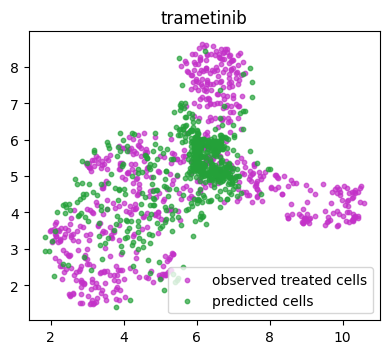

In [9]:
from umap import UMAP
import matplotlib.pyplot as plt

source = out["y_pred"][:, top_genes_idx]
target = Y_te_post[:, top_genes_idx]


# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)


fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C331C8")
ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#24A139")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

In [11]:
drug = "givinostat"
X_pre = adata_sc[adata_sc.obs["drug"] == "control"].copy().to_df()
X_post  = adata_sc[adata_sc.obs["drug"] == drug].copy().to_df()

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

top_genes_ids, top_genes_short, top_genes_idx = topk_markers(adata_sc, drug, k=100)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


X_pre cells: (17565, 1000)
X_post cells: (3541, 1000)
(2832, 1000)
(709, 1000)
(2832, 1000)
(709, 1000)
Median heuristic gamma: 0.0022147542823654246


In [12]:

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=3000, top_feature_subset=top_genes_idx, seed=seed)
  
    metrics = summarize_metrics(out["y_pred"][:, top_genes_idx], Y_te_post[:, top_genes_idx], median_gamma)
    all_metrics.append(metrics)

# Results summary
print("=== Metrics Summary over Runs for top 100 genes ===")
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

VERS torch=1.13.1+cu117 (CellOT), device=cuda


(2832, 1000)
(709, 1000)
(2832, 1000)
(709, 1000)
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 111/500:  22%|██████████████████████████████████████████████▌                                                                                                                                                                   | 111/500 [00:10<00:36, 10.59it/s, loss=30.9, v_num=1]
Monitored metric elbo_validation did not improve in the last 100 records. Best score: 291.400. Signaling Trainer to stop.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
[CellOT+scGen] epoch=0 f_loss=-451428.5625 g_loss=561849.2500 | train_mmd=0.7734 | test_mmd=0.7726 | test_mmd_cellot=0.2085
[CellOT+scGen] epoch=50 f_loss=-463607.6562 g_loss=769590.8125 | train_mmd=0.7592 | test_mmd=0.7555 | test_mmd_cellot=0.2045
[CellOT+scGen] epoch=100 f_loss=6841.3096 g_loss=-4710.3457 | train_mmd=0.7580 | test_mmd=0.7573 | test_mmd_cellot=0.2046
[CellOT+scGen] epoch=150 f_loss=-124334.4453 g_loss=159553.4375 | train_mmd=0.7294 | test_mmd=0.7291 | test_mmd_cellot=0.1960
[CellOT+scGen] epoch=200 f_loss=5675.8555 g_loss=-2475.3860 | train_mmd=0.7174 | test_mmd=0.7324 | test_mmd_cellot=0.1971
[CellOT+scGen] epoch=250 f_loss=14963.4385 g_loss=-5565.3574 | train_mmd=0.7720 | test_mmd=0.7737 | test_mmd_cellot=0.2129
[CellOT+scGen] epoch=300 f_l

...

**************** Run: 9 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 110/500:  22%|██████████████████████████████████████████████▏                                                                                                                                                                   | 110/500 [00:11<00:39,  9.93it/s, loss=30.4, v_num=1]
Monitored metric elbo_validation did not improve in the last 100 records. Best score: 286.038. Signaling Trainer to stop.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
[CellOT+scGen] epoch=0 f_loss=-598497.8125 g_loss=640485.5000 | train_mmd=0.7734 | test_mmd=0.7726 | test_mmd_cellot=0.2085
[CellOT+scGen] epoch=50 f_loss=-24595.8047 g_loss=39378.2148 | train_mmd=0.7496 | test_mmd=0.7479 | test_mmd_cellot=0.2025
[CellOT+scGen] epoch=100 f_loss=-109394.8281 g_loss=98986.9141 | train_mmd=0.7719 | test_mmd=0.7678 | test_mmd_cellot=0.2077
[CellOT+scGen] epoch=150 f_loss=-50698.0391 g_loss=52553.0703 | train_mmd=0.7951 | test_mmd=0.7663 | test_mmd_cellot=0.2065
[CellOT+scGen] epoch=200 f_loss=-2689.3538 g_loss=8269.8125 | train_mmd=0.5320 | test_mmd=0.5220 | test_mmd_cellot=0.1625
[CellOT+scGen] epoch=250 f_loss=4047.8203 g_loss=2099.7461 | train_mmd=0.1745 | test_mmd=0.1784 | test_mmd_cellot=0.1336
[CellOT+scGen] epoch=300 f_loss

=== Metrics Summary over Runs for top 100 genes ===
                        mean     std
mmd2_gamma_median     0.0117  0.0029
mmd2_gamma_0.5        0.0031  0.0002
mmd2_gamma_1.0        0.0029  0.0000
wasserstein_distance  7.0460  0.2342
R2_feature_means      0.7263  0.1355


In [13]:
drug = "abexinostat"
X_pre = adata_sc[adata_sc.obs["drug"] == "control"].copy().to_df()
X_post  = adata_sc[adata_sc.obs["drug"] == drug].copy().to_df()

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

top_genes_ids, top_genes_short, top_genes_idx = topk_markers(adata_sc, drug, k=100)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


X_pre cells: (17565, 1000)
X_post cells: (4505, 1000)
(3604, 1000)
(901, 1000)
(3604, 1000)
(901, 1000)
Median heuristic gamma: 0.0021515925828798567


In [14]:

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=3000, top_feature_subset=top_genes_idx, seed=seed)
  
    metrics = summarize_metrics(out["y_pred"][:, top_genes_idx], Y_te_post[:, top_genes_idx], median_gamma)
    all_metrics.append(metrics)

# Results summary
print("=== Metrics Summary over Runs for top 100 genes ===")
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))

VERS torch=1.13.1+cu117 (CellOT), device=cuda


(3604, 1000)
(901, 1000)
(3604, 1000)
(901, 1000)
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 108/500:  22%|█████████████████████████████████████████████▎                                                                                                                                                                    | 108/500 [00:13<00:48,  8.05it/s, loss=35.4, v_num=1]
Monitored metric elbo_validation did not improve in the last 100 records. Best score: 290.141. Signaling Trainer to stop.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
[CellOT+scGen] epoch=0 f_loss=-332769.3750 g_loss=401191.3125 | train_mmd=0.7779 | test_mmd=0.7750 | test_mmd_cellot=0.1946
[CellOT+scGen] epoch=50 f_loss=-27544.6230 g_loss=42753.5859 | train_mmd=0.7764 | test_mmd=0.7750 | test_mmd_cellot=0.1946
[CellOT+scGen] epoch=100 f_loss=213.1494 g_loss=-1023.6663 | train_mmd=0.7177 | test_mmd=0.7248 | test_mmd_cellot=0.1880
[CellOT+scGen] epoch=150 f_loss=5.1382 g_loss=-3210.9897 | train_mmd=0.9156 | test_mmd=0.9112 | test_mmd_cellot=0.3338
[CellOT+scGen] epoch=200 f_loss=-2001821.8750 g_loss=2017802.1250 | train_mmd=0.7079 | test_mmd=0.7239 | test_mmd_cellot=0.1843
[CellOT+scGen] epoch=250 f_loss=-23466209280.0000 g_loss=25389637632.0000 | train_mmd=0.8038 | test_mmd=0.7972 | test_mmd_cellot=0.2166
[CellOT+scGen] epoc

...

**************** Run: 9 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 107/500:  21%|████████████████████████████████████████████▉                                                                                                                                                                     | 107/500 [00:13<00:49,  7.90it/s, loss=35.4, v_num=1]
Monitored metric elbo_validation did not improve in the last 100 records. Best score: 279.837. Signaling Trainer to stop.
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
[CellOT+scGen] epoch=0 f_loss=-565391.7500 g_loss=794418.3125 | train_mmd=0.7776 | test_mmd=0.7750 | test_mmd_cellot=0.1946
[CellOT+scGen] epoch=50 f_loss=-146001.6875 g_loss=145786.9219 | train_mmd=0.6075 | test_mmd=0.6104 | test_mmd_cellot=0.1555
[CellOT+scGen] epoch=100 f_loss=-81192.5781 g_loss=100275.7969 | train_mmd=0.7245 | test_mmd=0.7314 | test_mmd_cellot=0.1847
[CellOT+scGen] epoch=150 f_loss=-45712.7812 g_loss=89077.0625 | train_mmd=0.7349 | test_mmd=0.7390 | test_mmd_cellot=0.1845
[CellOT+scGen] epoch=200 f_loss=1899.7690 g_loss=6165.4072 | train_mmd=0.3251 | test_mmd=0.3177 | test_mmd_cellot=0.0975
[CellOT+scGen] epoch=250 f_loss=-3070.1182 g_loss=5362.3442 | train_mmd=0.0969 | test_mmd=0.0954 | test_mmd_cellot=0.1006
[CellOT+scGen] epoch=300 f_lo

=== Metrics Summary over Runs for top 100 genes ===
                        mean     std
mmd2_gamma_median     0.0129  0.0063
mmd2_gamma_0.5        0.0022  0.0000
mmd2_gamma_1.0        0.0022  0.0000
wasserstein_distance  7.1009  0.8372
R2_feature_means      0.7460  0.1995
